# Chapter 8: Raster Data with NumPy and rasterio

*Part II — Geographic Data Science*

## Learning Objectives

By the end of this chapter you will be able to:

- Read and write GeoTIFF files with rasterio
- Apply raster algebra and focal operations with NumPy
- Understand the NumPy array as a simulation substrate

In [1]:
# Standard imports — add chapter-specific imports below
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio as rio
from rasterio.plot import show

Maranhão's coastline, the running example since Chapter 6, is almost perfectly flat — a poor advertisement for a chapter about elevation. This chapter borrows terrain from a hillier part of Brazil instead: an SRTM (Shuttle Radar Topography Mission) elevation grid over a microregion in Minas Gerais, centered on the town of Conselheiro Lafaiete. Chapter 13 brings the coast back once raster and vector start working together.

## Raster Data Model

A raster's defining structure is simple: a regular grid of rows and columns, one or more **bands** of values stacked on top of it (a single elevation band here; Chapter 9's climate data stacks dozens of time steps), and an **affine transform** — six numbers that map "row 340, column 12" to a real-world coordinate, so the grid can be placed on the Earth without storing a coordinate for every single cell.

Open a GeoTIFF with `rasterio.open()` and that structure is immediately inspectable, before reading a single pixel of actual data:

In [2]:
raster_path = "srtm_micro_lafaiete.tif"
src = rio.open(raster_path)

print("Bands:", src.indexes)
print("Data type:", src.dtypes)
print("Shape (rows, cols):", src.shape)
print("CRS:", src.crs)
print("Transform:", src.transform)

Bands: (1,)
Data type: ('int16',)
Shape (rows, cols): (1895, 3671)
CRS: EPSG:4326
Transform: | 0.00, 0.00,-44.42|
| 0.00,-0.00,-20.42|
| 0.00, 0.00, 1.00|


That `transform` is the raster analogue of the CRS work Chapter 6 did for vector data — it's what lets `rasterio` answer "where is pixel (340, 12)" the same way a `GeoDataFrame`'s geometry column answers "where is this polygon."

## Reading GeoTIFFs with rasterio

Metadata alone doesn't get you a NumPy array — that needs an explicit `.read()`, naming which band (bands are 1-indexed, not 0-indexed, one of rasterio's few surprises for anyone coming from NumPy):

<class 'numpy.ndarray'> (1895, 3671) int16


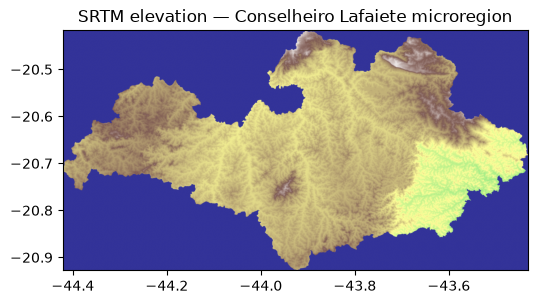

In [3]:
elevation = src.read(1)
print(type(elevation), elevation.shape, elevation.dtype)

fig, ax = plt.subplots(figsize=(6, 6))
show(elevation, cmap="terrain", transform=src.transform, ax=ax)
ax.set_title("SRTM elevation — Conselheiro Lafaiete microregion")
plt.show()

Real rasters almost always have a **nodata** value — a sentinel marking "no valid measurement here" (ocean, a sensor gap, a clipped edge), and it is not automatically `NaN`. SRTM tiles commonly use `0` for missing elevation, which is a genuinely bad default: `0` is also a perfectly plausible elevation at sea level, so a naive read can't tell "no data" apart from "this pixel is at sea level" without being told which is which:

In [ ]:
print("nodata as read:", src.nodata)

# Read with the mask applied — returns a masked array instead of raw numbers
masked_elevation = src.read(1, masked=True)
print(type(masked_elevation))
print("Valid pixels:", masked_elevation.count(), "of", masked_elevation.size)

If `src.nodata` came back `None` even though you know certain pixels are placeholders, the fix is the same pattern Chapter 4 used on messy tabular data — replace the sentinel with `NaN` explicitly, this time with `np.where` instead of `pd.to_numeric(errors="coerce")`:

In [ ]:
clean_elevation = np.where(elevation == 0, np.nan, elevation)
fig, ax = plt.subplots(figsize=(6, 6))
show(clean_elevation, cmap="terrain", transform=src.transform, ax=ax)
ax.set_title("After masking the 0-elevation sentinel")
plt.show()

## Raster Algebra

Once a raster is a NumPy array, every vectorized trick from Chapter 2 and Chapter 3 applies directly — arithmetic on an entire grid at once, no pixel-by-pixel loop required. A **hillshade**-style relief exaggeration is one line:

In [ ]:
exaggerated = clean_elevation * 2.5  # exaggerate relief for visualization
diff_from_mean = clean_elevation - np.nanmean(clean_elevation)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(exaggerated, cmap="terrain")
axes[0].set_title("Elevation × 2.5")
axes[1].imshow(diff_from_mean, cmap="RdBu_r")
axes[1].set_title("Deviation from mean elevation")
plt.show()

Boolean masks work exactly as they did on a `pandas` column in Chapter 4 — `clean_elevation > 900` returns a same-shaped array of `True`/`False`, directly usable both as a mask and, cast to `int`, as its own raster:

In [ ]:
highlands = clean_elevation > 900
print("Highland pixels:", np.nansum(highlands), "of", highlands.size)

plt.imshow(highlands, cmap="gray")
plt.title("Terrain above 900 m")
plt.show()

## Focal Operations with NumPy

Raster algebra combines a cell only with itself, across layers. A **focal** (or moving-window) operation instead combines each cell with its *neighbors* within the same layer — a smoothing filter, a slope estimate, anything where the output at one pixel depends on a small neighborhood around it. `scipy.ndimage` implements the common ones efficiently, entirely in terms of arrays rasterio and NumPy already produced:

In [ ]:
from scipy.ndimage import uniform_filter

smoothed = uniform_filter(clean_elevation, size=5)  # 5x5 moving-window mean

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(clean_elevation, cmap="terrain")
axes[0].set_title("Original")
axes[1].imshow(smoothed, cmap="terrain")
axes[1].set_title("5×5 moving-window mean")
plt.show()

A 5×5 uniform filter is deliberately the simplest possible focal operation — replace each cell with the mean of its neighborhood — but the pattern generalizes directly to anything Part III's cellular automata need: a fire-spread model checking whether *any* neighbor is burning, a diffusion model averaging a concentration across neighbors each step. Chapter 15 reaches for exactly this kind of neighborhood logic, just with rules instead of a mean.

## Multi-band Imagery

Every array so far has had one band — elevation, a single number per pixel. Satellite imagery is usually stacked: a Landsat scene ships red, green, blue, near-infrared, and more as separate bands sharing the same grid and transform. `rasterio` reads a multi-band file into a 3D array, shaped `(bands, rows, cols)`:

```python
# with a multi-band file open as `src`:
# stack = src.read()               # shape: (n_bands, rows, cols)
# red, nir = stack[2], stack[3]     # band order depends on the sensor
# ndvi = (nir - red) / (nir + red)  # a common per-pixel band algebra
```

That `ndvi` line is raster algebra again — Chapter 9 is where genuinely large, many-band stacks like this get a data structure built specifically for them (`xarray`, with named, labeled bands instead of a bare integer index).

## NumPy Array as a Simulation Grid

Chapter 7 closed by treating a `GeoDataFrame` as a simulation substrate, one row per cell. A NumPy array is the same idea in raster form — and, for a regular grid, usually the faster one: no geometry objects to intersect, just array indexing.

DisSModel's `RasterBackend`, which Chapter 8's counterpart in Part III (Chapter 18) introduces properly, wraps exactly this: a 2D (or 3D, for multiple state variables) NumPy array as a model's state, with each cell's eight neighbors reachable by simple index arithmetic — `grid[i-1:i+2, j-1:j+2]` — rather than a spatial join. The focal operation above is a preview of the mechanism every cellular automaton in Part III depends on: `rule()` reads a cell's neighborhood, computes a new value, and the *whole grid* updates via one vectorized NumPy expression, not a Python loop over cells. Chapter 17 comes back to explain exactly why that vectorization step matters as a grid grows from Lafaiete's few hundred pixels to a continental one.

## Exercises

1. **Nodata, correctly.** Confirm that `src.nodata` and the `0`-sentinel behave differently: count how many pixels equal exactly `0` in `elevation`, and compare that to `elevation.size - masked_elevation.count()`. Are they the same number? Should they be?
2. **A different focal size.** Rerun the *Focal Operations* smoothing with `size=15` instead of `size=5`. What visibly changes, and why does a larger window trade detail for smoothness?
3. **Threshold and count.** Using `clean_elevation`, find the elevation threshold above which exactly 10% of valid pixels fall (hint: `np.nanpercentile`). How does that threshold compare to the `900` m used in *Raster Algebra*?
4. **Sketch the neighbor math.** Without running any code, write out in words what `grid[i-1:i+2, j-1:j+2]` selects for a cell at position `(i, j)`, and how many cells that is in total. This is the exact slice Chapter 15's cellular automata use for a Moore neighborhood.

In [ ]:
# Your code here

## Summary

### Key concepts introduced

- The raster data model: a regular grid, one or more bands, and an affine transform placing it in real-world coordinates
- Reading a GeoTIFF with `rasterio.open()` and `.read()`, and why nodata sentinels (like SRTM's `0`) need explicit handling, not automatic detection
- Raster algebra: NumPy arithmetic and boolean masks applied to a whole grid at once, carrying Chapter 2's vectorization habit forward
- Focal (moving-window) operations with `scipy.ndimage`, as a preview of the neighborhood logic Part III's cellular automata run on every step
- Multi-band imagery as a 3D array, and a first look at per-pixel band algebra (NDVI)
- The NumPy array as a simulation substrate — DisSModel's `RasterBackend`, the raster counterpart to Chapter 7's `GeoDataFrame`-as-substrate

Chapter 9 stays in raster territory but swaps this chapter's single 2D grid for a full multidimensional, labeled stack — the shape real climate and land-cover time series actually come in.

## Further Reading

- rasterio documentation, *Reading and writing data*: <https://rasterio.readthedocs.io/en/stable/topics/reading.html>
- rasterio documentation, *Nodata masking*: <https://rasterio.readthedocs.io/en/stable/topics/masking-by-shapefile.html>
- NASA JPL, *Shuttle Radar Topography Mission (SRTM)*: <https://www2.jpl.nasa.gov/srtm/>
- scipy documentation, `scipy.ndimage` — the module behind this chapter's focal filter: <https://docs.scipy.org/doc/scipy/reference/ndimage.html>